In [1]:
import importlib as il
import numpy as np
import more_itertools as mit
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as spl
import linetimer as lt

import gurobipy as gp

import gurobi_utils as gu
import dikin_utils as du
import plot_utils as pu

import example_loader as el
import miplib_loader as ml
import jsplib_loader as jl

status_lookup = {getattr(gp.GRB.Status, k): k for k in gp.GRB.Status.__dir__() if "A" <= k[0] <= "Z"}

%matplotlib inline
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

What we want to do here:
1. Find an LP optimum for some problem.
2. Back away from that optimum into the interior sqrt(n)/2 distance.
3. Find the eigenvectors for Dikin's H at that point.
4. Round those to be integer values.
5. Run the LLL reduction on that result.
6. Make that be unimodular if it's not.
7. Transform the original problem and run the MIP solver for it.

In [2]:
def retreat_from_optimum_via_average_vector(V: np.ndarray, x: np.ndarray, target_distance):
    """Retreat from the optimum by moving in the direction of the average vector."""
    # this isn't perfect at the moment in that we should normalize the columns of V first.
    # that way each vector would contribute equally to the average.
    # however, some columns are zero-length, and we would have to handle that case.
    
    # normalize the columns first so that they all contribute equally:
    V /= np.linalg.norm(V, axis=0)

    avg = np.mean(V, axis=1)
    nrm = np.linalg.norm(avg) + 1e-5
    return x - avg * target_distance / nrm

def find_corner(relaxed: gp.Model, int_vars, int_var_idx):
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=0)
    negated_vars = [basis[nr] for nr in negated_rows]

    # the current understanding (from nlhdlr_quadratic.c in SCIP): 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    variables = relaxed.getVars()
    constraints = relaxed.getConstrs()
    for col, j in enumerate(col_to_var_idx):
        if j < len(variables):
            # print("Var INFO:", variables[j].VarName, "VBasis", variables[j].VBasis, "LB", variables[j].LB, "UB", variables[j].UB)
            if variables[j].VBasis == -2:
                # tableau[:, col] = variables[j].UB - tableau[:, col]
                tableau[:, col] = -tableau[:, col]
                print("   VBasis at -2 for", variables[j].VarName, variables[j].UB)
    #         if variables[j].VBasis == -1:  # not sure what to do with VBasis=-3
    #             tableau[:, col] = -tableau[:, col]  # variables[j].LB
    #             if variables[j].LB != 0.0:
    #                 print("Warning: LB is nonzero for variable", variables[j].VarName, "LB", variables[j].LB, "UB", variables[j].UB)
        else:
            constraint = constraints[j - len(variables)]
    #         # this might not be right: scip has status and tests for A_i*x being at lower or upper bound
    #         # if np.isclose(constraint.Slack, 0.0, atol=tol):
    #         #     tableau[:, col] = -tableau[:, col]
            if constraint.Sense == '>':  # Achterberg said lt and lte are standard; should just need to flip gt
                tableau[:, col] = -tableau[:, col]
                print("   GTE Constraint found for", constraint.ConstrName)

    # drop the rows of non-integer variables:
    to_drop = [i for i, b in enumerate(basis) if b not in int_var_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop) # update basis to match tableau

    # we want all the integer variables in order, assuming x, y as the first two.
    # however, some integer variables may be columns in the tableau, which is problematic.

    basis, tableau = mit.sort_together([basis, tableau], key_list=[0]) #, key=int_var_idx.get)
    tableau = np.array(tableau)

    sv = [int_vars[int_var_idx[b]].X for b in basis]
    return tableau, np.array(sv)

def make_primal_dual_values(mdl: gp.Model):
    """Extract primal and dual values from the model."""
    primal = np.array([v.X for v in mdl.getVars()])
    dual_cons = np.array([c.Pi for c in mdl.getConstrs()])
    # dual_vars = np.array([v.RC for v in mdl.getVars()])
    return primal, dual_cons

def get_A_b_c_l_u(mdl: gp.Model):
    mdl.update()
    A = mdl.getA()
    b = np.array(mdl.getAttr("RHS")).reshape(-1, 1)
    c = np.array(mdl.getAttr("Obj"))
    l = np.array(mdl.getAttr("LB"))
    u = np.array(mdl.getAttr("UB"))
    return A, b, c, l , u



In [3]:
import cvxpy as cp

def find_interior_point(old_model: gp.Model, distance, x0):
    old_model.update()
    r = cp.Variable(name="r", nonneg=True)
    new_vars = cp.Variable(old_model.NumVars, name="x")
    new_cons = []
    for i, v in enumerate(old_model.getVars()):
        ub = 1 if v.VType == 'B' else v.UB
        if ub < gp.GRB.INFINITY:
            new_cons.append(new_vars[i] + r <= ub)
        if v.LB > -gp.GRB.INFINITY: 
            new_cons.append(new_vars[i] - r >= v.LB)

    for constr in old_model.getConstrs():
        lhs_expr = old_model.getRow(constr)  # Get linear expression
        rhs_value = constr.RHS  # Get right-hand side
        sense = constr.Sense  # Get constraint type

        # Convert LHS to a CVXPY expression
        lhs_cvxpy = sum(lhs_expr.getCoeff(i) * new_vars[lhs_expr.getVar(i).index]
                        for i in range(lhs_expr.size()))
        
        multiplier = np.linalg.norm([lhs_expr.getCoeff(i) for i in range(lhs_expr.size())], 2)

        # Convert Gurobi sense to CVXPY constraint
        if sense == gp.GRB.LESS_EQUAL:
            new_cons.append(lhs_cvxpy + r * multiplier <= rhs_value)
        elif sense == gp.GRB.GREATER_EQUAL:
            new_cons.append(lhs_cvxpy - r * multiplier >= rhs_value)
        elif sense == gp.GRB.EQUAL:
            new_cons.append(lhs_cvxpy == rhs_value)

    new_cons.append(cp.sum_squares(new_vars - x0) <= distance ** 2)
    new_model = cp.Problem(cp.Maximize(r), new_cons)
    new_model.solve(solver=cp.GUROBI, verbose=False)

    if new_model.status == cp.OPTIMAL:
        x1 = new_vars.value
        r = r.value
        print("Interior point found:", x1, "r", r)
        return x1
    
    return None


(CVXPY) Feb 28 01:29:02 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.12.4544). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Feb 28 01:29:02 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.12.4544). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


Running: 2D from bottom
   Relaxed 2 variables on 2D from bottom
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2586148


Academic license 2586148 - for non-commercial use only - registered to br___@vt.edu
Interior point found: [1.16648094 1.77040099] r 0.3586382369906304
Code block 'Finding interior point' took: 28.84014 ms
   Negated 0 constraints on 2D from bottom
   Retreat to: [1.16648094 1.77040099]
Running: 2D no easy cut from bottom
   Relaxed 2 variables on 2D no easy cut from bottom
Interior point found: [3.00222615 2.30504145] r 0.48491029134585595
Code block 'Finding interior point' took: 13.53811 ms
   Negated 0 constraints on 2D no easy cut from bottom
   Retreat to: [3.00222615 2.30504145]
Running: 2D steep from bottom
   Relaxed 2 variables on 2D steep from bottom
Interior point found: [2.68157671 3.0953952 ] r 0.5649323402361517
Code block 'Finding interior point' took: 12.76001 ms
   Negated 0 constraints on 2D steep from bottom
   Retreat to: [2.68157671 3.0953952 ]
Running: 2D from top
   Relaxed 2 variables on 2D from top
Interior point found: [1.27796352 2.89626575] r 0.3586382819769

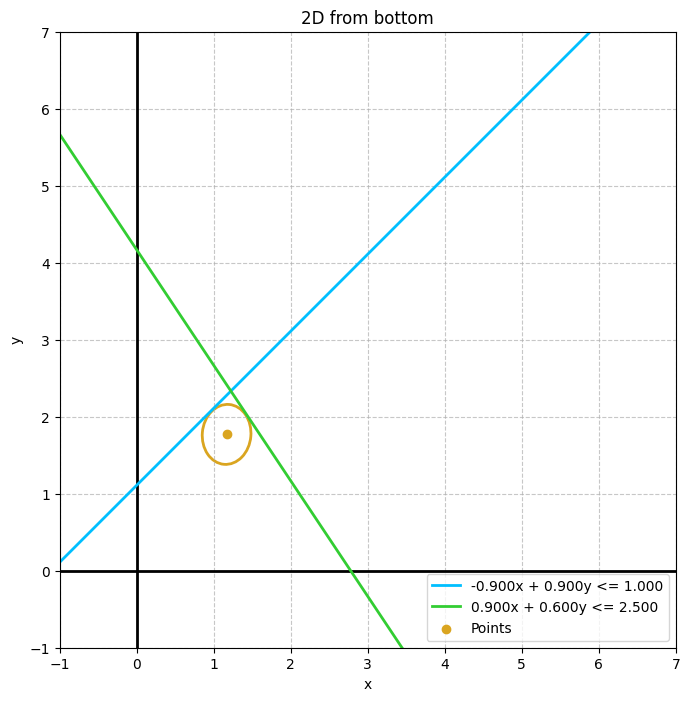

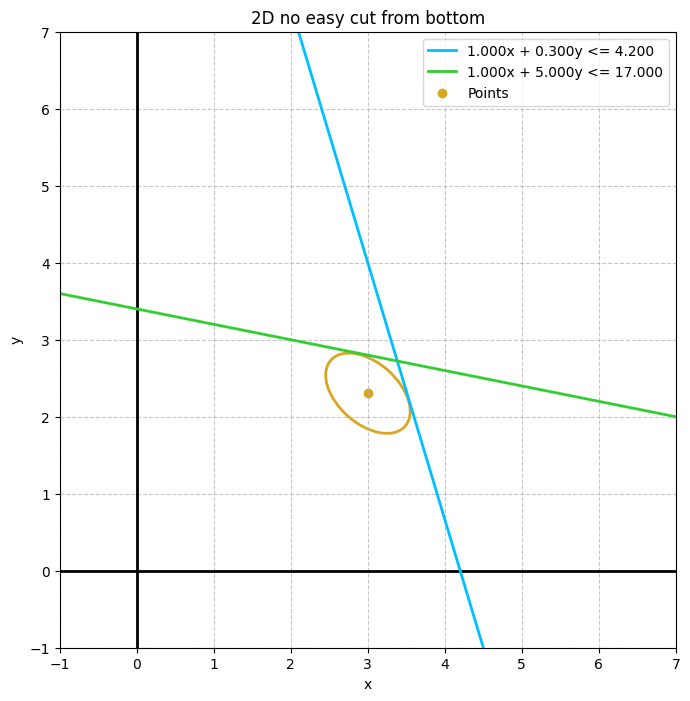

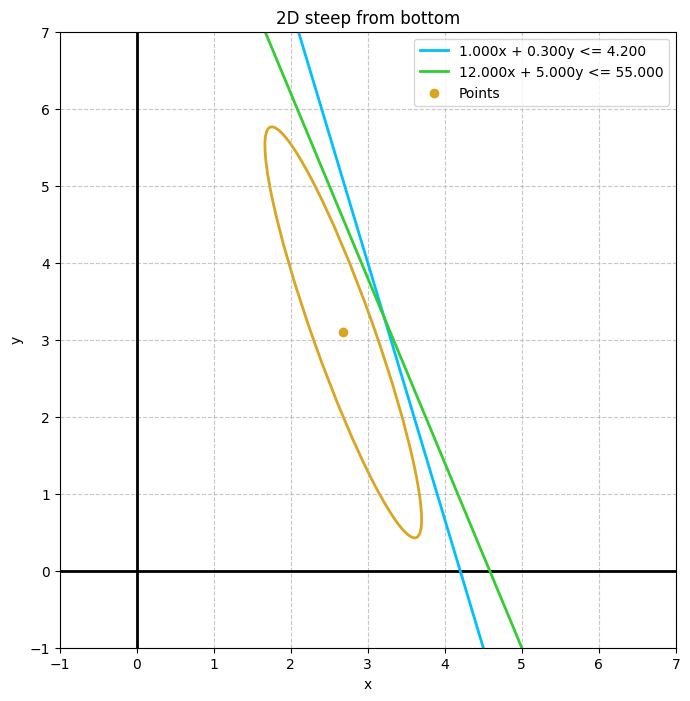

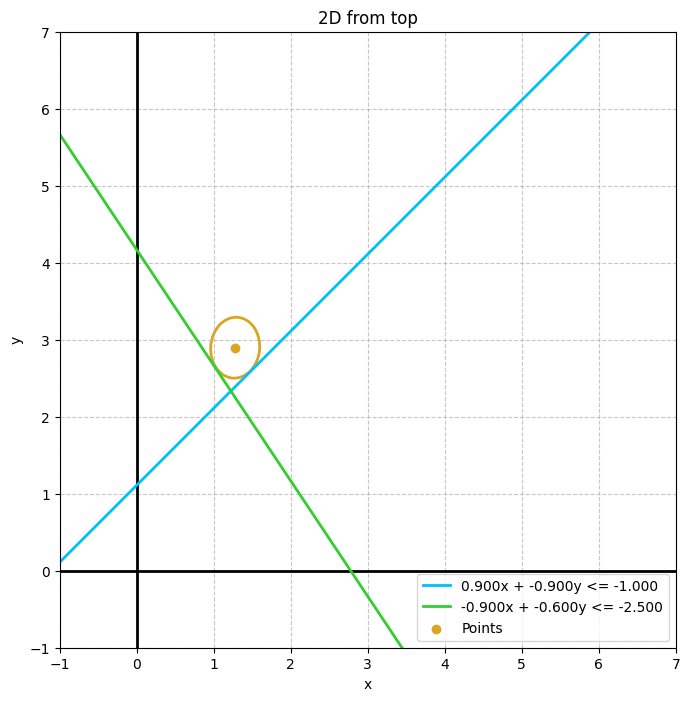

In [4]:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

def relax_and_shrink(mdl: gp.Model, diagonal_distance, percent_of_diagonal):
    mdl.update()
    relaxed = mdl.copy()
    if relaxed.NumIntVars > 0:
        _, _ = gu.relax_int_or_bin_to_continuous(relaxed)
    relaxed.update()
    if percent_of_diagonal == 0.0:
        return relaxed
    
    for v in relaxed.getVars():
        if v.UB - v.LB < percent_of_diagonal * 2.0:
            gap = (v.UB - v.LB) * percent_of_diagonal
            v.LB += gap
            v.UB -= gap
        else:
            if v.LB > -gp.GRB.INFINITY:
                v.LB += percent_of_diagonal
            if v.UB < gp.GRB.INFINITY:
                v.UB -= percent_of_diagonal

    distance = diagonal_distance * percent_of_diagonal
    for c in relaxed.getConstrs():
        lhs = relaxed.getRow(c)
        coeffs = np.array([lhs.getCoeff(i) for i in range(lhs.size())])
        if c.Sense == '<':
            c.RHS -= distance * np.linalg.norm(coeffs) / lhs.size()
        elif c.Sense == '>':
            c.RHS += distance * np.linalg.norm(coeffs) / lhs.size()
    relaxed.update()
    return relaxed

instances = el.get_instances(env)
for instance in list(instances.values())[0:4]:
    model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName)
    niv = model.NumIntVars
    _, _ = gu.relax_int_or_bin_to_continuous(model)
    model.optimize()
    x1 = np.array([v.X for v in model.getVars()])
    
    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.4, x1)    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.45)
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])
    # V, x = find_corner(model, int_vars, int_var_idx)
    # x2 = retreat_from_optimum_via_average_vector(V, x, np.sqrt(int_vars.size) * 0.4)
    # x, y = make_primal_dual_values(model)
    gu.standardize_gt_to_lt(model)
    A, b, c, lb, ub = get_A_b_c_l_u(model)
    # x2, its = du.least_squares_interior(A, b, x, l, u, d=np.sqrt(int_vars.size) * 0.4, infinity=gp.GRB.INFINITY)
    # x2, its = du.reverse_interior_point_gpt2(A, b, c, l, u, x, y, target_distance=np.sqrt(int_vars.size) * 0.4,
    #                                          infinity=10, is_maximizing=model.ModelSense == gp.GRB.MAXIMIZE)
    print("   Retreat to:", x2)
    senses = np.array(model.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, lb, ub, senses, points=[x2[:2]])
    du.plot_ellipse(A, b, lb, ub, x2, fig=fig)

    # gu.standardize_gt_to_lt(copy)
    # A, b, c, l, u = get_A_b_c_l_u(copy)
    # fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, points=[x2[:2]], fig=fig)


    # could assert x2 is feasible




In [ ]:
il.reload(du)
# test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
# test = np.array([[.1, -1, .3], [1, 0, 5], [1, 2, 6]])
H = np.array([[30, 7], [9, 10]])
# test = np.array([[1, 0, 5], [1, -1, 3], [1, 2, 6]])

U = du.CLLL_Post(H)
# import scipy.sparse as sps
# test = sps.csc_matrix(test)
# U = du.CLLL_Post(test)
H, U, np.linalg.det(U)

(array([[  7,  16],
        [ 10, -11]]),
 array([[ 0,  1],
        [ 1, -2]], dtype=int32),
 -1.0)

$$
H(x_0) = A^\top W(x_0) A + D(x_0),
$$
where:

1. $( W(x_0) )$ is a diagonal weight matrix for the inequality constraints $( Ax \leq b )$, defined as:
$$
W(x_0) = \text{diag}\left(\frac{1}{(b_i - A_i^\top x_0)^2}\right), \quad i = 1, 2, \dots, m.
$$
Here, $( b_i - A_i^\top x_0 > 0 )$ because $( x_0 )$ is an interior point.

2. $( D(x_0) )$ is a diagonal matrix that accounts for the bounds $( l \leq x \leq u )$, defined as:
$$
D(x_0) = \text{diag}\left( \frac{1}{(x_{0j} - l_j)^2} + \frac{1}{(u_j - x_{0j})^2} \right), \quad j = 1, 2, \dots, n.
$$
The terms $( x_{0j} - l_j > 0 )$ and $( u_j - x_{0j} > 0 )$ hold because $( x_0 )$ is an interior point.

For the transformation, define $x=Uy + x_0$. Then:

The variable bounds transformation: $U^{-1} (\ell_x - x_0) \leq y \leq U^{-1} (u_x - x_0)$

Constraints: $A U y \leq b - A x_0$

Objective: $(c^T U) y + c^T x_0 + c_0 = (U^T c)^T y + c^T x_0 + c_0$

In [7]:
def apply_transform(old_model: gp.Model, U: np.ndarray, x0: np.ndarray, basis=None, normalize_Ab=False, mult=1):
    """Apply the transformation U to the model."""
    old_model.update()
    # A, b, c, l, u = get_A_b_c_l_u(result) # for debug

    # going to shift it to 0, then apply the transformation, then shift it back (all in one operation):
    # going with this substitution: y=U_inv(x - x0) + x0 so x=U(y - x0) + x0
    # and for Ax <= b: AUy <= b + A(Ux0 - x0)
    # and for c^T x: c^T Uy - c^T U x0 + c^T x0
    # and for l <= x <= u: l - x0 <= U (y - x0) <= u - x0  # keep U in the middle or it will mess with the inequality direction

    # Ensure unimodular_matrix has the correct dimensions
    num_vars = old_model.NumVars
    if basis is None and U.shape != (num_vars, num_vars):
        raise ValueError("Unimodular matrix must have dimensions matching the number of variables.")

    # Get original data
    A = old_model.getA()  # Constraint coefficient matrix (as a scipy.sparse matrix)
    b = old_model.getAttr("RHS")  # Right-hand side vector
    sense = old_model.getAttr("Sense")  # Constraint senses (<=, >=, =)
    lb = np.array(old_model.getAttr("LB"))
    ub = np.array(old_model.getAttr("UB"))

    if normalize_Ab:
        for i in range(A.shape[0]):
            if b[i] == 0.0:
                A[i, :] /= np.abs(A[i, :].toarray()).max()
            else:
                A[i, :] /= np.abs(b[i])
                b[i] = np.sign(b[i])

    U_inv = np.linalg.inv(U)
    variables = old_model.getVars()
    if basis is not None:
        assert len(basis) == U.shape[0]
        all_indices = np.arange(num_vars)
        mask = np.ones(all_indices.shape, dtype=bool)
        mask[basis] = False
        non_basis = all_indices[mask]
        new_order = np.concatenate((basis, non_basis))
        variables = [variables[i] for i in new_order]
        x0 = x0[new_order]
        lb = lb[new_order]
        ub = ub[new_order]
        eye = sp.eye(num_vars - len(basis))
        U_inv = sp.block_diag([U_inv, eye], format='csr')
        U = sp.block_diag([U, eye], format='csr')
        # columns of A must also be sorted to match the new basis
        A = A[:, new_order]

    vtypes = []
    for idx, v in enumerate(variables):
        if v.VType == gp.GRB.BINARY:
            lb[idx] = 0.0
            ub[idx] = 1.0
            vtypes.append(gp.GRB.INTEGER)
        else:
            vtypes.append(v.VType)
    vtypes = np.array(vtypes)

    # lb[lb < -gp.GRB.INFINITY] = -gp.GRB.INFINITY  # we can't have infinities when we multiply by 0
    # ub[ub > gp.GRB.INFINITY] = gp.GRB.INFINITY

    # we translate it by x0, do the transform, then transform it back -x0
    lb -= x0
    ub -= x0

    # Create a new model
    new_model = gp.Model(name=f"{old_model.ModelName}_transformed")

    # Add new variables y corresponding to the transformed space
    y_vars = new_model.addMVar(num_vars, lb=-gp.GRB.INFINITY, vtype=vtypes, name=f"y")
    Uyx = U @ (y_vars - x0)
    new_model.addConstr(lb <= Uyx * mult, name="lb")
    ub_idx = ub < gp.GRB.INFINITY
    if np.any(ub_idx):
        new_model.addConstr(ub[ub_idx] >= Uyx[ub_idx] * mult, name="ub")

    for idx, variable in enumerate(variables):
        y_vars[idx].VarName = variable.VarName

    A_transformed = A @ U
    b_deduction = A @ (U @ x0 - x0)

    # Add the transformed constraints AUy <= b (or other senses)
    for i in range(A_transformed.shape[0]):
        expr = A_transformed[i, :] @ y_vars * mult
        if sense[i] == '<':
            new_model.addConstr(expr <= b[i] + b_deduction[i], name=f"lt_{i}")
        elif sense[i] == '>':
            new_model.addConstr(expr >= b[i] + b_deduction[i], name=f"gt_{i}")
        elif sense[i] == '=':
            new_model.addConstr(expr == b[i] + b_deduction[i], name=f"eq_{i}")

    # Transform the objective
    obj_coeffs = np.array([v.Obj for v in variables])  # more efficient way?
    obj = model.getObjective()
    new_model.setObjective(obj_coeffs @ U @ y_vars * mult - obj_coeffs @ U @ x0 + obj_coeffs @ x0 + obj.getConstant(), old_model.ModelSense)
    new_model._y_vars = y_vars
    new_model._U = U
    new_model._U_inv = U_inv
    new_model._x0 = x0
    new_model._basis = basis

    return new_model

def exp_scale_2(V: np.ndarray, u: np.ndarray, eps = 1):
    # M = e^s *V + (1-e^s)(uu^T)V
    M = np.exp(-eps) * V + (1 - np.exp(-eps)) * (u@u.T)@V
    return M

def to_det_1(A: np.ndarray):
    # A = A * (det(A))^-1/20
    dim = A.shape[0]
    return A * (np.abs(np.linalg.det(A)) ** (-1/dim))

In [ ]:
# simple approach: just skew it
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)
il.reload(jl)

instances = el.get_instances(env)
# instances = jl.get_instances()
for instance in list(instances.values())[0:3]:
    # model = instance.as_gurobi_balas_model(use_big_m=True)  # env=env
    model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName, model.NumIntVars)

    # relaxed = relax_and_shrink(model, 0.0, 0.0)
    # relaxed.params.LogToConsole = 0
    # with lt.CodeTimer("Finding relaxed optimum"):
    #     relaxed.optimize()
    # x1 = np.array([v.X for v in relaxed.getVars()]) # + [c.Slack for c in relaxed.getConstrs()])

    c = np.array(model.getAttr("Obj"))
    # U = np.array([[1, -2], [0, 1]])
    n = len(c)
    # U = np.triu(-np.ones((n, n)), k=1)
    U = np.zeros((n, n))
    variables = model.getVars()
    int_idxs = [v.index for v in variables if v.VType != gp.GRB.CONTINUOUS]
    for i, idx in enumerate(int_idxs[:-1]):
        U[idx, int_idxs[i + 1]] = -1
    np.fill_diagonal(U, 1)
    x0 = np.zeros_like(c)
    model2 = apply_transform(model, U, x0)
    model2.params.LogToConsole = 0
    relaxed_vars, base_to_relaxed = gu.relax_int_or_bin_to_continuous(model2)
    for t in range(2):
        model2.optimize()
        print("\nStatus", model2.Status)
        if model2.Status == gp.GRB.OPTIMAL:
            print("Objective:", model2.ObjVal)
        cuttable_rows = list(gu.find_cuttable_rows(model2, base_to_relaxed))
        print("Cuttables:", len(cuttable_rows))
        for variable, go_smaller in cuttable_rows:
            print("   Cuttable variable:", variable.VarName, "go_smaller", go_smaller, variable.X)
            if go_smaller:
                variable.UB = np.round(variable.X - 0.501)
            else:
                # if np.isclose(variable.X % 1, 0, atol=1e-5):
                #     variable.LB = np.ceil(variable.X + 0.5)
                # else:
                variable.LB = np.round(variable.X + 0.501)
        model2.update()
    # if model2.Status == gp.GRB.OPTIMAL:
    #     print("Objective:", model2.ObjVal)
    #     x3 = np.array([v.X for v in model2.getVars()])
    #     U_inv = np.linalg.inv(U) # return it to original space
    #     x4 = U @ (x3 - (x0 - U_inv @ x0))
    #     print("X3, X4", x3, x4)  # expect x4 to be integer if transform is actually unimodular
    # else:
    #     print("Model2 not optimal:", status_lookup[model2.Status])

    if n < 4:
        A, b, c, l, u = get_A_b_c_l_u(model2)
        senses = np.array(model2.getAttr("Sense"))
        fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, senses)

In [187]:
# simple approach: make constraints more parallel to the objective:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)
il.reload(jl)

# instances = el.get_instances(env)
instances = jl.get_instances()
for instance in list(instances.values())[7:8]:
    model = instance.as_gurobi_balas_model(use_big_m=True)  # env=env
    # model = instance.as_gurobi_model()
    model.params.LogToConsole = 0
    print("Running:", model.ModelName, model.NumIntVars)
    model.update()
    with lt.CodeTimer("Optimizing"):
        model.optimize()
    print("Found solution:", model.ObjVal)

    c = np.array(model.getAttr("Obj")).reshape(-1, 1)
    nc = np.linalg.norm(c)
    # alpha = (1 - np.cos(np.pi*0.25)) / nc #  np.array([[0.65], [0.6]])
    # alpha = np.tan(np.pi*0.75) / nc
    alpha = 0.35

    A = model.getA()  # Constraint coefficient matrix (as a scipy.sparse matrix)
    b = model.getAttr("RHS")  # Right-hand side vector

    for i in range(A.shape[0]):
        if b[i] == 0.0:
            A[i, :] /= np.abs(A[i, :].toarray()).max()
        else:
            A[i, :] /= np.abs(b[i])
            b[i] = np.sign(b[i])

    w = np.zeros((A.shape[0], 1))
    for i in range(A.shape[0]):
        row = A[i, :].toarray()  # TODO: keep it sparse
        w[i, 0] = (row @ c).item() / (np.linalg.norm(row) * nc)

    v = np.sign(w)
    warp = (sp.eye_array(A.shape[0]) - alpha * v @ w.T)
    # model2 = apply_transform(model, warp, np.zeros(c.shape[0]), normalize_Ab=True)
    # warp = np.linalg.inv(warp)
    # U = warp # / np.linalg.norm(warp, axis=0) # du.CLLL(warp)
    U = du.CLLL_Post(warp)
    A2 = U @ A
    b2 = U @ b

    model2 = gp.Model(name=f"{model.ModelName}_warped")
    model2.params.LogToConsole = 0
    x2 = []
    for var in model.getVars():
        x2.append(model2.addVar(var.LB, var.UB, var.Obj, var.VType, var.VarName))
    # x2 = gp.MVar.fromlist(x2)
    senses = np.array(model.getAttr("Sense"))
    model2.addMConstr(A2, x2, senses, b2.flatten(), name="warped")

    model2.update()
    with lt.CodeTimer("Optimizing"):
        model2.optimize()
    print("Status", model2.Status, "Found other solution:", model2.ObjVal, "\n")


    # A, b, c, l, u = get_A_b_c_l_u(model2)
    # fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u)
    # du.plot_ellipse(A, b, l, u, x, fig=fig)


Set parameter LogToConsole to value 0
Running: abz5 0
Code block 'Optimizing' took: 4473.90491 ms
Found solution: 1234.0
Set parameter LogToConsole to value 0
Code block 'Optimizing' took: 9051.40520 ms
Status 2 Found other solution: 1234.0 



Running: 2D no easy cut from bottom
   Relaxed 2 variables on 2D no easy cut from bottom_copy
Interior point found: [3.00222615 2.30504145] r 0.48491029134585595
Code block 'Finding interior point' took: 30.44139 ms
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
   Relaxed 2 variables on 2D no easy cut from bottom_transformed
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "EndeavourOS")

CPU model: Intel(R) Core(TM) i7-8750H CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
Heuristics  0
Cuts  0
Presolve  0

Academic license 2586148 - for non-commercial use only - registered to br___@vt.edu
Optimize a model with 4 rows, 2 columns and 6 nonzeros
Model fingerprint: 0xd1bc1fe7
Coefficient statistics:
  Matrix range     [2e-01, 5e+00]
  Objective ran

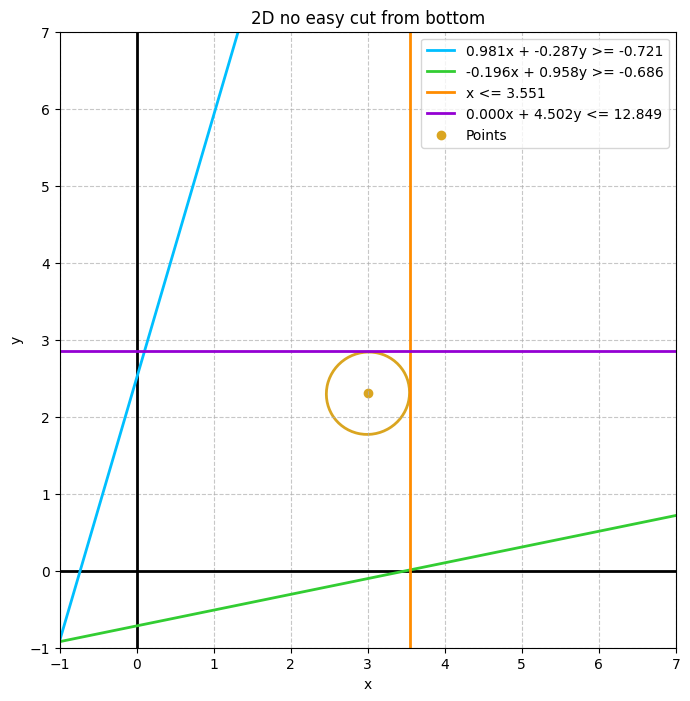

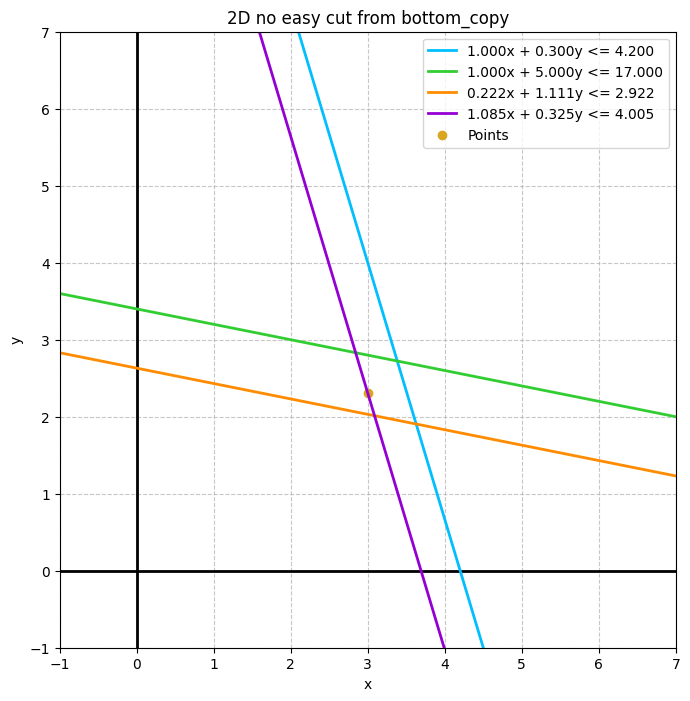

In [18]:
# bring the corner in so that it's acute
# or just use the tableau so we get axis-aligned vectors

il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

instances = el.get_instances(env)
# instances = jl.get_instances()
for instance in list(instances.values())[1:2]:
    # model = instance.as_gurobi_balas_model(use_big_m=True, env=env)
    model = instance.as_gurobi_model()
    print("Running:", model.ModelName)

    relaxed = relax_and_shrink(model, 0.0, 0.0)
    relaxed.optimize()
    x1 = np.array([v.X for v in relaxed.getVars()]) # + [c.Slack for c in relaxed.getConstrs()])

    niv = model.NumIntVars
    assert niv > 0
    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.1)
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])


    # get the corner vectors
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, remove_basis_cols=True)
    gu.fix_tableau_dirs(relaxed, tableau, col_to_var_idx)
    tableau /= np.linalg.norm(tableau, axis=0)  # normalize column vectors

    # x2_bas = retreat_from_optimum_via_average_vector(tableau, x1[basis], np.sqrt(niv)* 0.45)
    # x2 = np.zeros_like(x1)
    # x2[basis] = x2_bas

    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.4, x1)

    direction = (x1 - x2).reshape(-1, 1)  # vectors point away by default
    # direction = np.ones((tableau.shape[0], 1))  # vectors point away by default

    # I can't have more columns than rows going into the CLLL.
    # So I need to reduce the number of columns.
    # I could do this by removing the columns that are linearly dependent.
    # But there's probably not too many of those.
    # I could just choose the first n columns or I could choose a random set.
    # Ideally I would choose the columns that are most orthogonal to the direction vector.
    # Code to do that would be:
    if tableau.shape[1] > tableau.shape[0]:
        keepers = np.argsort(np.abs(np.dot(tableau.T, direction).flatten()))[::-1]
        tableau = tableau[:, keepers[:tableau.shape[0]]]

    # scaled = exp_scale_2(tableau, direction, eps=0.0)  # could negate dir or tableau
    scaled = tableau
    # scaled = to_U_via_LU(scaled, 0.27)
    # scaled = to_det_1(scaled)
    # orig = scaled.copy()
    # B2, U = du.lll_reduction_deepseek(scaled)
    U = scaled #  du.CLLL_Post(scaled)

    # either we make the matrix big enough for all variables, or we make it only apply to the basis variables.
    # if we do the former, I don't have to drop any columns. However, that's likely much larger and requires sparse handling.

    model2 = apply_transform(model, U, x2, basis)  # np.zeros_like(x2)
    model2.params.Presolve = 0
    model2.params.Heuristics = 0
    model2.params.Cuts = 0
    _, _ = gu.relax_int_or_bin_to_continuous(model2)
    model2.optimize()
    A, b, c, l, u = get_A_b_c_l_u(model2)
    # model2.params.LogToConsole = 0
    # model2.optimize()
    # x3 = np.array([v.X for v in model2.getVars()])
    # # return it to original space:
    # U_inv = np.linalg.inv(U)
    # x4 = U_inv @ (x3 - (x2 - U @ x2))
    # print("X3, X4", x3, x4)

    senses = np.array(model2.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, senses, points=[x2[:2]])
    du.plot_ellipse(A, b, l, u, x2, fig=fig)

    assert model2.Status == gp.GRB.OPTIMAL
    basis = gu.read_basis(model2)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(model2, basis, remove_basis_cols=True)
    gu.fix_tableau_dirs(model2, tableau, col_to_var_idx)

    # x=U(y - x0) + x0 so y=U_inv(x - x0) + x0
    # so for y_i <= 2, we have (U_inv(x - x0) + x0)_i <= 2
    x = gp.MVar.fromlist(relaxed.getVars())
    y = model2._U_inv @ (x - x2) + x2
    for i, row in zip(basis, -tableau):
        # we can only cut vars that are supposed to be integers, but how can we tell which those are?
        if np.all(row > -1e-5):
            relaxed.addConstr(y[i] >= np.ceil(model2._y_vars[i].X))
        elif np.all(row < 1e-5):
            relaxed.addConstr(y[i] <= np.floor(model2._y_vars[i].X))

    A, b, c, l, u = get_A_b_c_l_u(relaxed)
    senses = np.array(relaxed.getAttr("Sense"))
    fig = pu.plot_constraints_lte(relaxed.ModelName, A, b, l, u, senses, points=[x2[:2]])
    # du.plot_ellipse(A, b, l, u, x2, fig=fig)

Running: 2D from bottom
   Relaxed 2 variables on 2D from bottom_copy
Interior point found: [1.16648094 1.77040099] r 0.3586382369906304
Code block 'Finding interior point' took: 33.09549 ms
   Negated 0 constraints on 2D from bottom
Determinant: 1.0 , U: [[1. 0.]
 [0. 1.]]
Set parameter LogToConsole to value 0
X3, X4 [1. 2.] [1. 2.]
Running: 2D no easy cut from bottom
   Relaxed 2 variables on 2D no easy cut from bottom_copy
Interior point found: [3.00222615 2.30504145] r 0.48491029134585595
Code block 'Finding interior point' took: 27.60816 ms
   Negated 0 constraints on 2D no easy cut from bottom
Determinant: 1.0 , U: [[1. 0.]
 [0. 1.]]
Set parameter LogToConsole to value 0
X3, X4 [3. 2.] [3. 2.]
Running: 2D steep from bottom
   Relaxed 2 variables on 2D steep from bottom_copy
Interior point found: [2.68157671 3.0953952 ] r 0.5649323402361517
Code block 'Finding interior point' took: 25.52223 ms
   Negated 0 constraints on 2D steep from bottom
Determinant: 1.0 , U: [[ 1.  0.]
 [-2. 

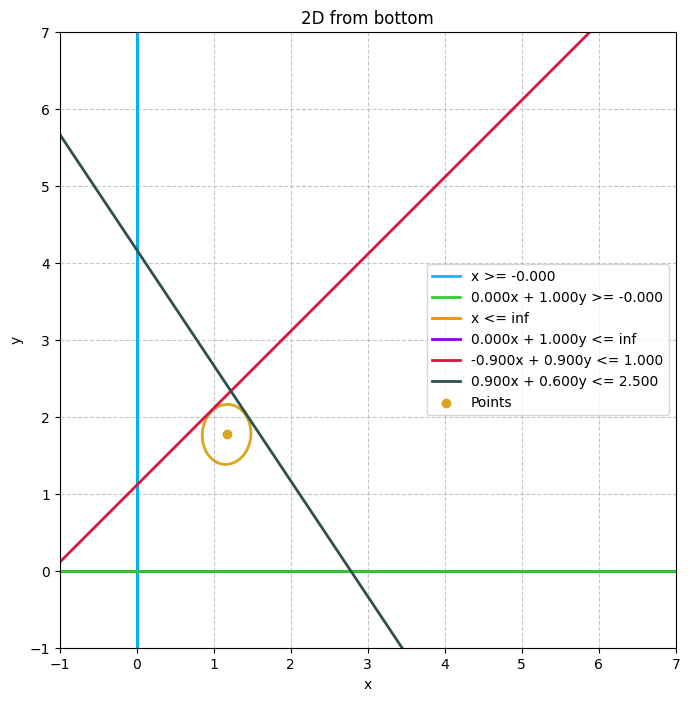

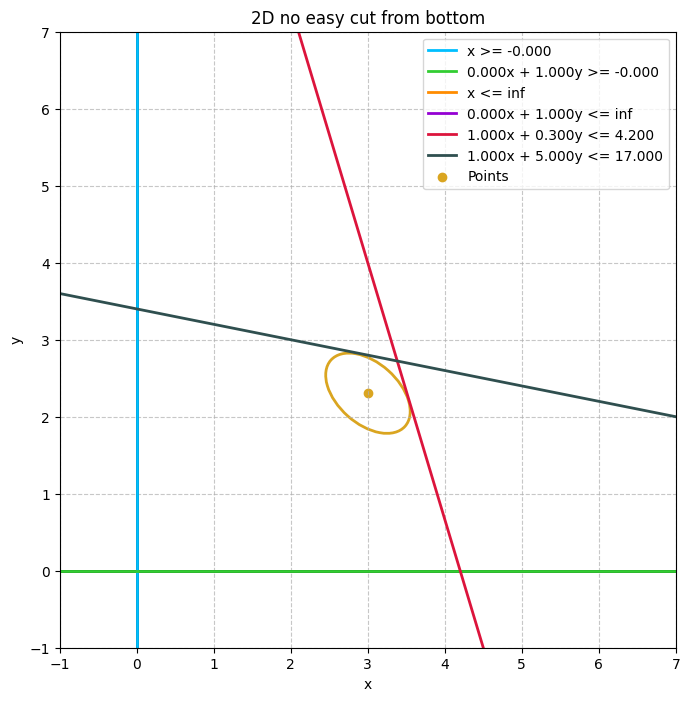

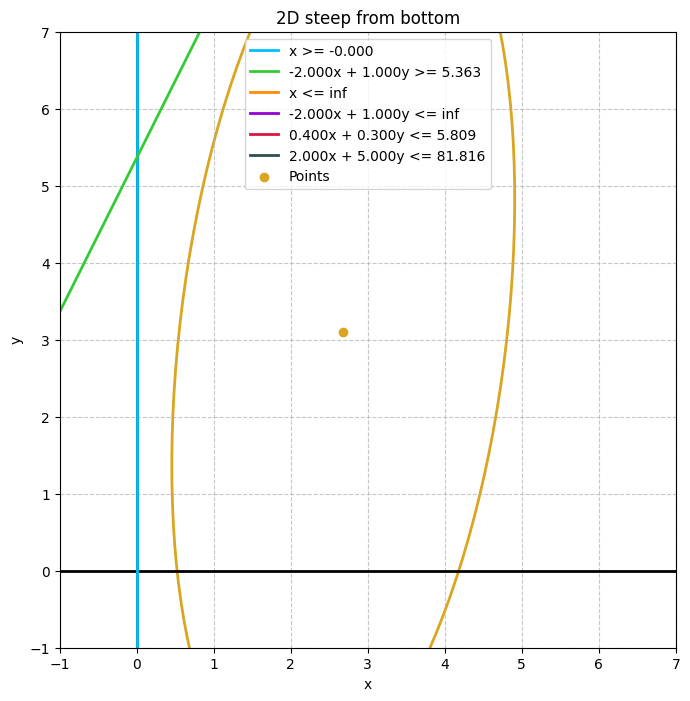

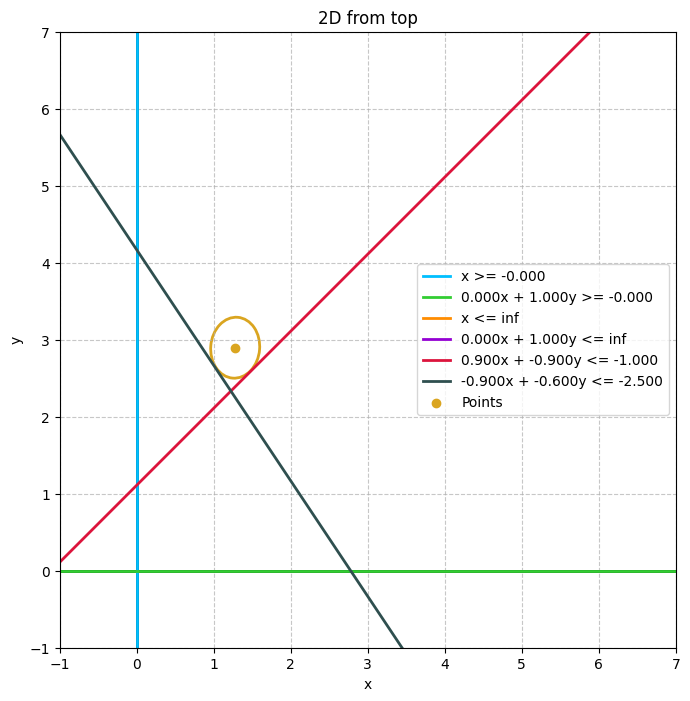

In [178]:
# make the Dikin ellipsoid be round:

il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

instances = el.get_instances(env)
# instances = jl.get_instances()
def to_U_via_SNF(R, mult=100, keep_scale=False):
    SU, SD, SV = du.smith_normal_form_ds(R * mult)
    for i in range(SD.shape[0]):
        for j in range(i, SD.shape[1]):
            if i == j:
                if not keep_scale:
                    SD[i, j] = np.sign(SD[i, j])
                continue
            if abs(SD[i, j]) < abs(SD[j, i]):
                SD[i, j] = 0
            else:
                SD[j, i] = 0
    return np.linalg.inv(SU) @ SD @ np.linalg.inv(SV)

def to_U_via_LU(R, mult=1):
    P, L, U = spl.lu(R, overwrite_a=False)
    for i in range(L.shape[0]):
        div = L[i, i]
        if div != 0.0:
            L[i, :] /= abs(div)
        div = U[i, i]
        if div != 0.0:
            U[i, :] /= abs(div)

    L = np.round(L * np.sqrt(mult))
    U = np.round(U * np.sqrt(mult))
    
    return np.linalg.inv(P) @ L @ U

for instance in list(instances.values())[0:4]:
    # model = instance.as_gurobi_balas_model(use_big_m=True, env=env)
    model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName)

    niv = model.NumIntVars
    assert niv > 0

    relaxed = relax_and_shrink(model, 0.0, 0.0)
    relaxed.optimize()
    x1 = np.array([v.X for v in relaxed.getVars()]) # + [c.Slack for c in relaxed.getConstrs()])

    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.45)
    # shrunk.params.LogToConsole = 0
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])
    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.4, x1)

    gu.standardize_gt_to_lt(model)
    A, b, c, l, u = get_A_b_c_l_u(model)
    
    H = du.compute_H(A, b, l, u, x2)  # h.shape == (n, n)
    H = H.toarray()  # for small projects
    import scipy.linalg as spl
    H2 = spl.sqrtm(H)  # TODO: add a more efficient eigenvalue decomposition for the sqrt
    # U = to_U_via_SNF(H2)

    H2 = np.linalg.inv(H2)
    # U = H2
    # U = to_U_via_LU(H2, mult=1)
    # U = to_U_via_SNF(H2, 2)
    # U = du.CLLL_Pre(H2)  # modifies H2
    U = du.CLLL_Post(H2, 0.7)
    U = np.linalg.inv(U.T)
    
    print("Determinant:", np.linalg.det(U), ", U:", U)

    model2 = apply_transform(model, U, x2, mult=1)
    A, b, c, l, u = get_A_b_c_l_u(model2)

    model2.params.LogToConsole = 0
    model2.optimize()
    if model2.Status == gp.GRB.OPTIMAL:
        x3 = np.array([v.X for v in model2.getVars()])
        # return it to original space:
        U_inv = np.linalg.inv(U)
        x4 = U @ (x3 - (x2 - U_inv @ x2))
        print("X3, X4", x3, x4)  # expect x4 to be integer if transform is actually unimodular
    else:
        print("Model2 not optimal:", model2.Status)

    senses = np.array(model2.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, senses, points=[x2[:2]])
    du.plot_ellipse(A, b, l, u, x2, fig=fig)


Define $x=Uy + x_0$. Then:

The variable bounds transformation: $U^{-1} (\ell_x - x_0) \leq y \leq U^{-1} (u_x - x_0)$

Constraints: $A U y \leq b - A x_0$

Objective: $(c^T U) y + c^T x_0 + c_0$

In [ ]:
import jsplib_loader as jl
instances = jl.get_instances()
instance = instances["abz5"]
model = instance.as_gurobi_model()
print("Running:", model.ModelName)

shrunk = relax_and_shrink(model, np.sqrt(niv), 0.3)
shrunk.optimize()
x2 = np.array([v.X for v in shrunk.getVars()])

gu.standardize_gt_to_lt(model)
A, b, c, l, u = get_A_b_c_l_u(model)

H = du.compute_H(A, b, l, u, x2)
import scipy.linalg as spl
R = spl.sqrtm(H.toarray())  # TODO: add a more efficient eigenvalue decomposition for the sqrt
R = np.round(R * 1000)
U = du.CLLL(R)  # modifies H2
print("Determinant:", np.linalg.det(U))

model2 = apply_transform(model, U, x2)
model2.optimize()

Set parameter AggFill to value 10
Set parameter GomoryPasses to value 1
Running: abz5
   Relaxed 1000 variables on abz5_copy
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "EndeavourOS")

CPU model: Intel(R) Core(TM) i7-8750H CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
GomoryPasses  1
AggFill  10

Academic license 2586148 - for non-commercial use only - registered to br___@vt.edu
Optimize a model with 1000 rows, 1101 columns and 2900 nonzeros
Model fingerprint: 0xfe912e72
Coefficient statistics:
  Matrix range     [1e+00, 8e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [3e-01, 7e-01]
  RHS range        [5e+01, 5e+03]
Presolve removed 451 rows and 550 columns
Presolve time: 0.01s
Presolved: 549 rows, 1001 columns, 2007 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.6285695e+02   1.190179e+03   0.000000e+00      0s
   